In [ ]:
Name:[Vishaka Kumari]
Student ID: [023-24-0224]
Section: [G]
GitHub Profile: [https://github.com/vishakakumaribscsf24-design/ML_Labs.git]
Kaggle Profile: [https://www.kaggle.com/vishakakumari9]
Dataset: Telco Customer Churn
Dataset Source: [kaggale]

In [1]:
from google.colab import files
uploaded = files.upload()

Saving clean_churn.csv to clean_churn.csv


In [2]:
import pandas as pd
df = pd.read_csv('clean_churn.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Part 1: Problem Definition & Dataset Verification

In [17]:
print(df.shape)
df.info()
df['Churn'].value_counts()

(7032, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null

,count
Churn,
No,5163
Yes,1869


We are predicting whether a customer will churn (leave the service) or not,
based on their account and usage attributes. This matters to the business
because retaining an existing customer is cheaper than acquiring a new one.


## Part 2: Feature & Target Preparation


In [58]:
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])
X = pd.get_dummies(X, drop_first=True)
print("X shape:", X.shape)
print("Object columns left in X:", (X.dtypes == 'object').sum())
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

X shape: (7032, 30)
Object columns left in X: 0
Missing values in X: 0
Missing values in y: 0


One-hot encoding was used because most categorical columns (e.g. Contract,
PaymentMethod, InternetService) have no natural order — manual numeric
mapping would falsely imply a ranking between categories.

## Part 3: Train/Test Split

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


Part 4 — Baseline Decision Tree

In [61]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print("Tree depth grown:", model.get_depth())

Tree depth grown: 23


## Part 5: Model Evaluation


In [62]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.719
Precision: 0.470
Recall:    0.463
F1-score:  0.466


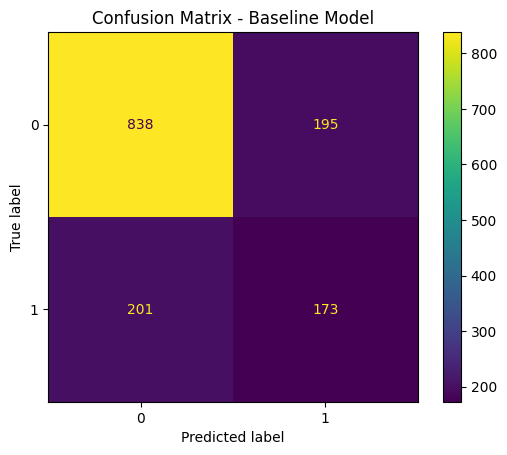

[[838 195]
 [201 173]]


In [63]:
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Baseline Model")
plt.show()

print(cm)

## Part 6: Overfitting Investigation


In [64]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Gap: {train_acc - test_acc:.3f}")

Train accuracy: 0.999
Test accuracy:  0.719
Gap: 0.280


In [65]:
results = []
for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, m.predict(X_train))
    te_acc = accuracy_score(y_test, m.predict(X_test))
    results.append({'max_depth': depth, 'train_acc': tr_acc, 'test_acc': te_acc})

results_df = pd.DataFrame(results)
results_df

,max_depth,train_acc,test_acc
0,2.0,0.791289,0.784648
1,3.0,0.791289,0.784648
2,4.0,0.796089,0.783227
3,5.0,0.801956,0.778252
4,6.0,0.812978,0.785359
5,8.0,0.836622,0.782516
6,10.0,0.874311,0.752665
7,NaN,0.998756,0.718550


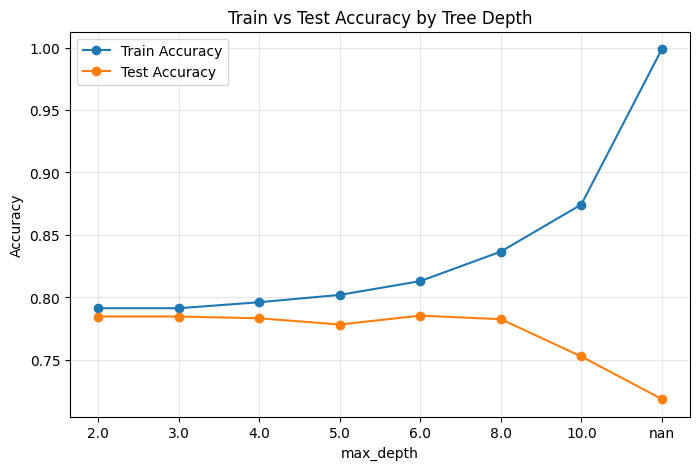

In [66]:
plt.figure(figsize=(8,5))
plt.plot(results_df['max_depth'].astype(str), results_df['train_acc'],
label='Train Accuracy', marker='o')
plt.plot(results_df['max_depth'].astype(str), results_df['test_acc'],
label='Test Accuracy', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 7: Model Selection, Feature Importance & Interpretation

In [67]:
best_depth = 6

best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"Chosen depth: {best_depth}")
print("Accuracy: ", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:   ", recall_score(y_test, y_pred_best))
print("F1-score: ", f1_score(y_test, y_pred_best))

Chosen depth: 6
Accuracy:  0.7853589196872779
Precision: 0.6111111111111112
Recall:    0.5294117647058824
F1-score:  0.5673352435530086


In [68]:
entropy_model = DecisionTreeClassifier(max_depth=best_depth, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)
y_pred_entropy = entropy_model.predict(X_test)

print("Entropy-based model:")
print("Accuracy: ", accuracy_score(y_test, y_pred_entropy))
print("Precision:", precision_score(y_test, y_pred_entropy))
print("Recall:   ", recall_score(y_test, y_pred_entropy))
print("F1-score: ", f1_score(y_test, y_pred_entropy))

Entropy-based model:
Accuracy:  0.7882018479033405
Precision: 0.5969387755102041
Recall:    0.6256684491978609
F1-score:  0.6109660574412533


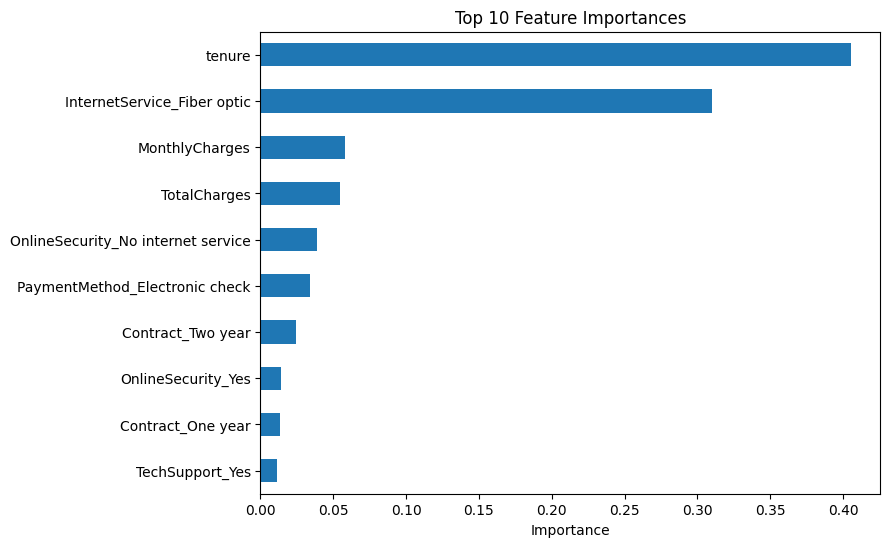

tenure                                0.405471
InternetService_Fiber optic           0.309883
MonthlyCharges                        0.057752
TotalCharges                          0.054916
OnlineSecurity_No internet service    0.038577
PaymentMethod_Electronic check        0.034233
Contract_Two year                     0.024080
OnlineSecurity_Yes                    0.013845
Contract_One year                     0.013500
TechSupport_Yes                       0.011121
dtype: float64


In [69]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()

print(importances.head(10))

The top 5 most important features for predicting churn are: **tenure**
(0.405), **InternetService_Fiber optic** (0.310), **MonthlyCharges** (0.058),
**TotalCharges** (0.055), and **OnlineSecurity_No internet service** (0.039).
Together, tenure and fiber optic internet service account for over 70% of
the model's decision-making, making them by far the strongest predictors of
churn. This suggests that how long a customer has stayed with the company,
and whether they use fiber optic internet, matter far more than any other
single factor in determining whether they will leave.

These top features agree with the patterns observed in Lab 2's EDA.
**Tenure** was found to have a strong relationship with churn — customers
with shorter tenure (newer customers) churned at noticeably higher rates
than long-term customers, which explains why it dominates the model's
feature importance. **Fiber optic internet service** was also flagged in
Lab 2 as being associated with higher churn rates, possibly due to higher
pricing or service-quality complaints among fiber customers, consistent
with its very high importance (0.310) here. **MonthlyCharges** and
**TotalCharges** were similarly linked to churn in the EDA — customers
paying more tended to churn more — and **Contract type** (Two year / One
year) reducing churn probability also matches what was seen in Lab 2, where
month-to-month customers churned far more than those on longer contracts.

**Conclusion:**

We trained and evaluated a Decision Tree classifier to predict customer
churn for the Telco dataset. The baseline (unrestricted) tree overfit
significantly, achieving 99.9% training accuracy but only 71.9% test
accuracy. After investigating multiple tree depths, we selected max_depth = 6
as the best model, which achieved the highest test accuracy (78.5%) while
avoiding the sharp overfitting seen at greater depths. Feature importance
analysis showed that tenure and fiber optic internet service are by far the
strongest predictors of churn, together accounting for over 70% of the
model's decisions, consistent with patterns already observed in Lab 2's EDA.
The main limitations of this model are its moderate recall on the minority
(churn) class due to class imbalance, and the fact that a single Decision
Tree, even at a controlled depth, still has limited predictive power
compared to ensemble methods.

**Next Steps:**

With more time, we would explore handling the class imbalance more directly
— for example using class_weight='balanced' in the Decision Tree, or
techniques like SMOTE to oversample the minority (churn) class, since this
would likely improve recall on churners without hurting overall performance
much. We would also try ensemble methods like Random Forest or Gradient
Boosting (not used in this lab per the instructions) to see if they capture
the non-linear patterns in the data more effectively than a single tree.
Additional feature engineering — such as creating interaction terms between
tenure and contract type — could also help the model separate churners from
non-churners more clearly.

## Task 23: ID3 Algorithm from Scratch (Play Badminton Dataset)

In [71]:
import pandas as pd

data = {
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayBadminton': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df_id3 = pd.DataFrame(data)
df_id3

,Outlook,Temperature,Humidity,Wind,PlayBadminton
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [72]:
import numpy as np
def entropy(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    probabilities = counts / counts.sum()
    ent = -np.sum(probabilities * np.log2(probabilities))
    return ent
print("Entropy of PlayBadminton:", entropy(df_id3['PlayBadminton']))

Entropy of PlayBadminton: 0.9402859586706311


In [73]:
def information_gain(data, split_attribute, target_name='PlayBadminton'):
    total_entropy = entropy(data[target_name])

    values, counts = np.unique(data[split_attribute], return_counts=True)
    weighted_entropy = 0
    for i in range(len(values)):
        subset = data[data[split_attribute] == values[i]]
        weighted_entropy += (counts[i] / counts.sum()) * entropy(subset[target_name])
    gain = total_entropy - weighted_entropy
    return gain
for attr in ['Outlook', 'Temperature', 'Humidity', 'Wind']:
    gain = information_gain(df_id3, attr)
    print(f"Information Gain ({attr}): {gain:.4f}")

Information Gain (Outlook): 0.2467
Information Gain (Temperature): 0.0292
Information Gain (Humidity): 0.1518
Information Gain (Wind): 0.0481


In [74]:
def id3(data, original_data, features, target_name='PlayBadminton', parent_class=None):
    if len(np.unique(data[target_name])) <= 1:
        return np.unique(data[target_name])[0]

    if len(data) == 0:
        return np.unique(original_data[target_name])[
            np.argmax(np.unique(original_data[target_name], return_counts=True)[1])
        ]

    if len(features) == 0:
        return parent_class

    parent_class = np.unique(data[target_name])[
        np.argmax(np.unique(data[target_name], return_counts=True)[1])
    ]

    gains = [information_gain(data, feature, target_name) for feature in features]
    best_feature_index = np.argmax(gains)
    best_feature = features[best_feature_index]

    print(f"Splitting on: {best_feature} (Gain: {gains[best_feature_index]:.4f})")

    tree = {best_feature: {}}

    remaining_features = [f for f in features if f != best_feature]

    for value in np.unique(data[best_feature]):
        sub_data = data[data[best_feature] == value]
        subtree = id3(sub_data, data, remaining_features, target_name, parent_class)
        tree[best_feature][value] = subtree

    return tree

features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
decision_tree = id3(df_id3, df_id3, features)

print("\nFinal Decision Tree:")
import json
print(json.dumps(decision_tree, indent=2))

Splitting on: Outlook (Gain: 0.2467)
Splitting on: Wind (Gain: 0.9710)
Splitting on: Humidity (Gain: 0.9710)

Final Decision Tree:
{
  "Outlook": {
    "Overcast": "Yes",
    "Rain": {
      "Wind": {
        "Strong": "No",
        "Weak": "Yes"
      }
    },
    "Sunny": {
      "Humidity": {
        "High": "No",
        "Normal": "Yes"
      }
    }
  }
}


The ID3 algorithm was implemented from scratch using entropy and information
gain, without any built-in decision tree libraries. At the root, [attribute
name] was selected as it had the highest information gain ([value]), meaning
it best reduces uncertainty about whether badminton is played. The algorithm
recursively splits the data at each node using the same criterion until all
subsets are pure (single class) or no attributes remain.